In [37]:
from glob import glob
from tqdm import tqdm

from matplotlib import pyplot as plt

import numpy as np
import pandas as pd
import mdtraj as md

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

## Some conclusions from this notebook:

* Changes in unit cell parameters appear to describe most of the variation in the data, but not all.
* The 3rd PC doesn't correlate well with any cell parameter. The data cluster in two groups along this linear direction. Currently, what causes this variation in the data is unknown.

In [2]:
def compute_volume(df):
    # only for monoclinic...
    df['volume'] = df['a'] * df['b'] * df['c'] * np.sin(np.radians(df['beta'])) / 1000. # nm^3
    return


def traj_to_cell_dataframe(traj):
    data = np.hstack([ traj.unitcell_lengths * 10, traj.unitcell_angles ])
    df = pd.DataFrame(data, columns=['a', 'b', 'c', 'alpha', 'beta', 'gamma'])
    compute_volume(df)
    return df


def dir_to_trj(path, load_cells=False):
    
    pdb_list = glob(path + '/*.pdb')
    print('found %d hit pdbs' % len(pdb_list))

    structures = None
    cells = []
    
    for pdb in tqdm(pdb_list):

        try:

            trj = md.load_pdb(pdb)
            idx = trj.top.select('(type != H) and is_protein')
            trj = trj.atom_slice(idx)

            if structures:
                structures = structures.join(trj)
            else:
                structures = trj
                
            if load_cells:
                cell = np.concatenate( [trj.unitcell_lengths[0]*10.0,
                                        trj.unitcell_angles[0], 
                                        trj.unitcell_volumes] )
                cells.append(cell)

        except Exception as e:
            print(pdb, e)
            print(trj.n_atoms, structures.n_atoms)

    structures = structures.center_coordinates()
    print('final num loaded:', len(structures))

    if load_cells:
        cells = np.array(cells)
        return structures, cells
    else:
        return structures
    
    
def featurize_all_dihedrals(traj):
    
    features = []
    for fxn in [md.compute_phi,
                md.compute_psi]:
        _, angles = fxn(traj)
        
        features.append( np.sin(angles) )
        features.append( np.cos(angles) )
    
    return np.hstack(features)

In [3]:
SELECTED_DATASET_PDBS = '/Users/tjlane/Desktop/selected_dataset_archive_2024-08-07/pdb'
apo_wcell, cells = dir_to_trj(SELECTED_DATASET_PDBS, load_cells=True)

found 1146 hit pdbs


100%|██████████| 1146/1146 [02:02<00:00,  9.39it/s]

final num loaded: 1146


## PCA on Torsion Angles

In [4]:
pca = PCA(n_components=8, svd_solver='full', whiten=True)

X_tr = featurize_all_dihedrals(apo_wcell)
Y_tr = pca.fit_transform(X_tr)

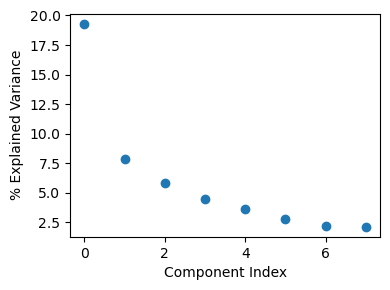

0.27127516
0.4810366


In [54]:
plt.figure(figsize=(4,3))
plt.plot(pca.explained_variance_ratio_ * 100, 'o')
plt.xlabel('Component Index')
plt.ylabel('% Explained Variance')

plt.tight_layout()
plt.savefig('figures/pca_explained_variance.pdf')
plt.show()

print(pca.explained_variance_ratio_[0] + pca.explained_variance_ratio_[1])
print(np.sum(pca.explained_variance_ratio_[:10]))

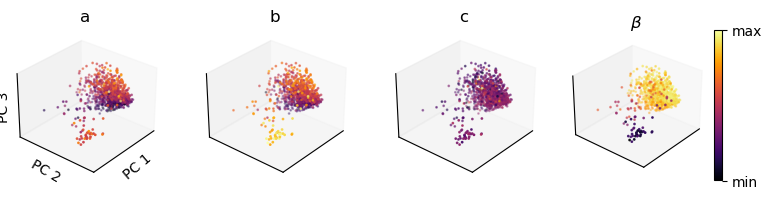

In [6]:
# the top 3 PCs

cell_labels = ['a', 'b', 'c', r'$\alpha$', r'$\beta$', r'$\gamma$', 'V']

fig = plt.figure(figsize=(8, 2))

for ax_i in range(4):

    ax = fig.add_subplot(1, 4, ax_i+1, projection='3d', elev=30, azim=40)

    if ax_i == 3:
        c_i = 4 # fourth plot beta
    else:
        c_i = ax_i

    ax.set_title(cell_labels[c_i])
    
    s = ax.scatter( Y_tr[:,0], 
                   -Y_tr[:,1], 
                    Y_tr[:,2], 
                   cmap='inferno',
                   s=1,
                   c=cells[:,c_i])

    if ax_i == 0:
        ax.set_xlabel('PC 1', labelpad=-12, rotation=40)
        ax.set_ylabel('PC 2', labelpad=-12, rotation=-30)
        ax.set_zlabel('PC 3', labelpad=-15, rotation=90)

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])

cbar = fig.colorbar(s, ticks=[cells[:,c_i].min(), cells[:,c_i].max()])
cbar.ax.set_yticklabels(['min', 'max']) 
    
plt.tight_layout()
plt.savefig('./figures/cell_params_v_structure_PCA_torsion.pdf')
plt.show()

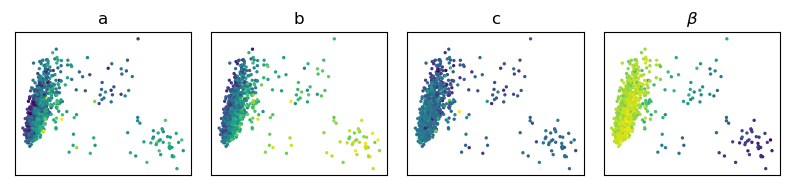

In [7]:
fig = plt.figure(figsize=(8,2))

for ax_i in range(4):

    ax = fig.add_subplot(1, 4, ax_i+1)
    ax.set_xticks([])
    ax.set_yticks([])

    if ax_i == 3:
        c_i = 4 # fouth plot beta
    else:
        c_i = ax_i

    ax.set_title(cell_labels[c_i])
    plt.scatter(Y_tr[:,0], Y_tr[:,1], s=2, c=cells[:,c_i])
    
plt.tight_layout()
plt.show()

## tSNE on Torsions

In [8]:
Y_sne = TSNE(n_components=2, init='pca', perplexity=10.0).fit_transform(X_tr)

/opt/homebrew/Caskroom/miniforge/base/lib/python3.10/site-packages/sklearn/manifold/_t_sne.py:810: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/lib/python3.10/site-packages/sklearn/manifold/_t_sne.py:996: FutureWarning: The PCA initialization in TSNE will change to have the standard deviation of PC1 equal to 1e-4 in 1.2. This will ensure better convergence.
  warnings.warn(


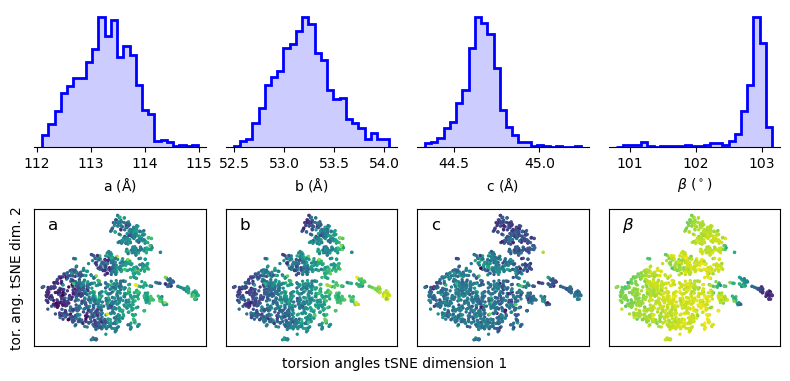

In [9]:
bins = 25

fig = plt.figure(figsize=(8,4))

for ax_i in range(4):

    ax = fig.add_subplot(2, 4, ax_i+1)
    
    if ax_i == 3:  # fourth plot beta
        c_i = 4
        unit = r" ($^\circ$)"
    else:
        c_i = ax_i
        unit = r" ($\mathrm{\AA}$)"
        
    ax.set_xlabel(cell_labels[c_i] + unit)
    ax.spines[['right', 'top', 'left']].set_visible(False)
    ax.set_yticks([])

    ax.hist(cells[:,c_i], histtype="step", color="blue", lw=2, bins=bins)
    s = ax.hist(cells[:,c_i], alpha=0.2, color="blue", bins=bins)


for ax_i in range(4, 8):

    ax = fig.add_subplot(2, 4, ax_i+1)
    
    if ax_i == 4:
        ax.set_ylabel("tor. ang. tSNE dim. 2", fontsize=10)
    
    if ax_i == 7:  # fourth plot beta
        c_i = 4
    else:
        c_i = ax_i - 4

    s = ax.scatter(
        Y_sne[:,0] / Y_sne[:,0].max(), 
        Y_sne[:,1] / Y_sne[:,1].max(), 
        s=2, 
        c=cells[:,c_i]
    )

    ax.set_xticks([])
    ax.set_yticks([])
    ax.text(-0.7, 0.80, cell_labels[c_i], fontsize=12)

fig.supxlabel("torsion angles tSNE dimension 1", x=0.5, y=0.06, fontsize=10)

plt.tight_layout()
# plt.savefig('./figures/torsion_tSNE.pdf')
plt.show()

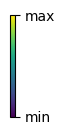

In [10]:
plt.figure(figsize=(1, 2))

img = plt.imshow(np.array([[0,1]]))
plt.gca().set_visible(False)

cbar = plt.colorbar(orientation="vertical", ticks=[0,1])
cbar.ax.set_yticklabels(['min', 'max'])

plt.tight_layout()
# plt.savefig("./figures/colorbar.pdf")

plt.show()

## T-SNE control


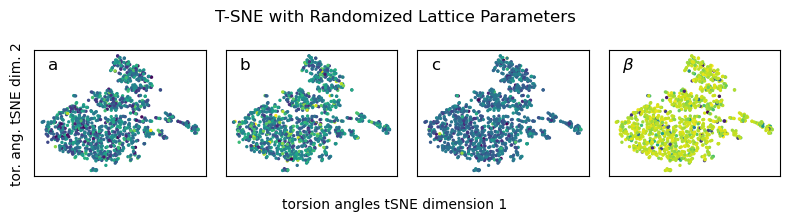

In [11]:
bins = 25

fig = plt.figure(figsize=(8,2.2))
plt.suptitle("T-SNE with Randomized Lattice Parameters")

for ax_i in range(4):

    ax = fig.add_subplot(1, 4, ax_i+1)
        
    if ax_i == 0:
        ax.set_ylabel("tor. ang. tSNE dim. 2", fontsize=10)

    if ax_i == 3:  # fourth plot beta
        c_i = 4
    else:
        c_i = ax_i

    ax.set_xticks([])
    ax.set_yticks([])
    ax.text(-0.7, 0.80, cell_labels[c_i], fontsize=12)
    
    s = ax.scatter(
        Y_sne[:,0] / Y_sne[:,0].max(), 
        Y_sne[:,1] / Y_sne[:,1].max(), 
        s=2, 
        c=np.random.permutation(cells[:,c_i])
    )

fig.supxlabel("torsion angles tSNE dimension 1", x=0.5, y=0.06, fontsize=10)

plt.tight_layout()
# plt.savefig('./figures/torsion_tSNE_randomized_control.pdf')
plt.show()

## clustering control

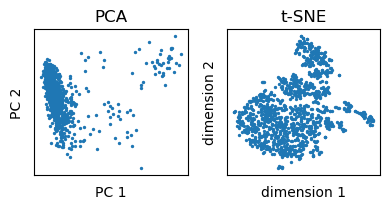

In [24]:
fig = plt.figure(figsize=(4,2.2))
# plt.suptitle("T-SNE with Randomized Lattice Parameters")

ax = fig.add_subplot(1, 2, 1)
ax.set_title("PCA")
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")

ax.set_xticks([])
ax.set_yticks([])
    
s = ax.scatter( 
    Y_tr[:,0],           
    -Y_tr[:,1],
    s=2,
)


ax = fig.add_subplot(1, 2, 2)
ax.set_title("t-SNE")
ax.set_xlabel("dimension 1")
ax.set_ylabel("dimension 2")

ax.set_xticks([])
ax.set_yticks([])
    
s = ax.scatter(
    Y_sne[:,0] / Y_sne[:,0].max(), 
    Y_sne[:,1] / Y_sne[:,1].max(),  
    s=2,
)

# fig.supxlabel("torsion angles tSNE dimension 1", x=0.5, y=0.06, fontsize=10)

plt.tight_layout()
# plt.savefig('./figures/torsion_tSNE_randomized_control.pdf')
plt.show()

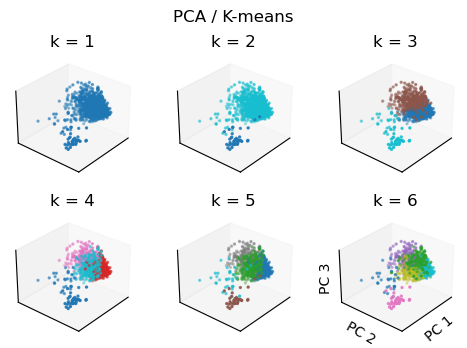

In [53]:
from sklearn.cluster import KMeans

fig = plt.figure(figsize=(5, 10))
plt.suptitle("PCA / K-means")

K = 6
num_pcs = 10

for k in range(1, K+1):

    ax = fig.add_subplot(K, 3, k, projection='3d', elev=30, azim=40)
    ax.set_title(f"k = {k}")

    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = kmeans.fit_predict(Y_tr[:,:num_pcs])

    ax.scatter(
        Y_tr[:, 0],
        -Y_tr[:, 1],
        Y_tr[:, 2],
        s=2,
        c=labels,
        cmap='tab10',
        label=f"Cluster {k}"
    )
    labels = kmeans.fit_predict(Y_tr)

    if k == K:
        ax.set_xlabel('PC 1', labelpad=-12, rotation=40)
        ax.set_ylabel('PC 2', labelpad=-12, rotation=-30)
        ax.set_zlabel('PC 3', labelpad=-15, rotation=90)

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])

plt.tight_layout()
plt.savefig('./figures/pca-kmeans.pdf')
plt.show()